In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

In [2]:
df = pd.read_csv('sdf22_2a.txt', sep='\t', low_memory=False)

#convert to numeric 
number_columns = ['MEMBERSCH', 'TOTALREV', 'TFEDREV', 'TSTREV', 'TLOCREV', 'C14']

for col in number_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in number_columns:
    df.loc[df[col] < 0, col] = np.nan

#keep only regular operating districts!
clean = df[df['UNIT_TYPE'].astype(str) == '5'].copy()

# positive enrollment
clean = clean[clean['MEMBERSCH'] > 0]
# positive revenue 
clean = clean[clean['TOTALREV'] > 0]

# per-pupil revenue values
clean['pp_total'] = clean['TOTALREV'] / clean['MEMBERSCH']
clean['pp_local'] = clean['TLOCREV'] / clean['MEMBERSCH']
clean['pp_state'] = clean['TSTREV'] / clean['MEMBERSCH']

# revenue percentages
clean['pct_local'] = (clean['TLOCREV'] / clean['TOTALREV']) * 100
clean['pct_state'] = (clean['TSTREV'] / clean['TOTALREV']) * 100
clean['pct_federal'] = (clean['TFEDREV'] / clean['TOTALREV']) * 100

state_rows = []

for state_name, group in clean.groupby('STABBR'):
    total_students = group['MEMBERSCH'].sum()
    total_revenue = group['TOTALREV'].sum()
    total_title1 = group['C14'].sum()
    total_local = group['TLOCREV'].sum()
    total_state = group['TSTREV'].sum()
    total_federal = group['TFEDREV'].sum()

    row = {
        'STABBR': state_name,
        'pp_total': total_revenue / total_students,
        'pp_titleI': total_title1 / total_students,
        'pct_local': (total_local / total_revenue) * 100,
        'pct_state': (total_state / total_revenue) * 100,
        'pct_federal': (total_federal / total_revenue) * 100
    }

    state_rows.append(row)

state = pd.DataFrame(state_rows)

# inequality stats
def get_state_inequality(group):
    per_pupil = group['pp_total'].dropna()

    if len(per_pupil) < 5:
        return None

    result = {
        'p10': per_pupil.quantile(0.10),
        'median': per_pupil.median(),
        'p90': per_pupil.quantile(0.90),
        'pct_local': (group['TLOCREV'].sum() / group['TOTALREV'].sum()) * 100,
        'pct_state': (group['TSTREV'].sum() / group['TOTALREV'].sum()) * 100,
        'total_students': group['MEMBERSCH'].sum()
    }

    return pd.Series(result)

# apply the inequality function to each state
stats = clean.groupby('STABBR').apply(get_state_inequality, include_groups=False)

# remove states that returned None
stats = stats.dropna().reset_index()

# calculate the p90 - p10 gap
stats['dollar_gap'] = stats['p90'] - stats['p10']

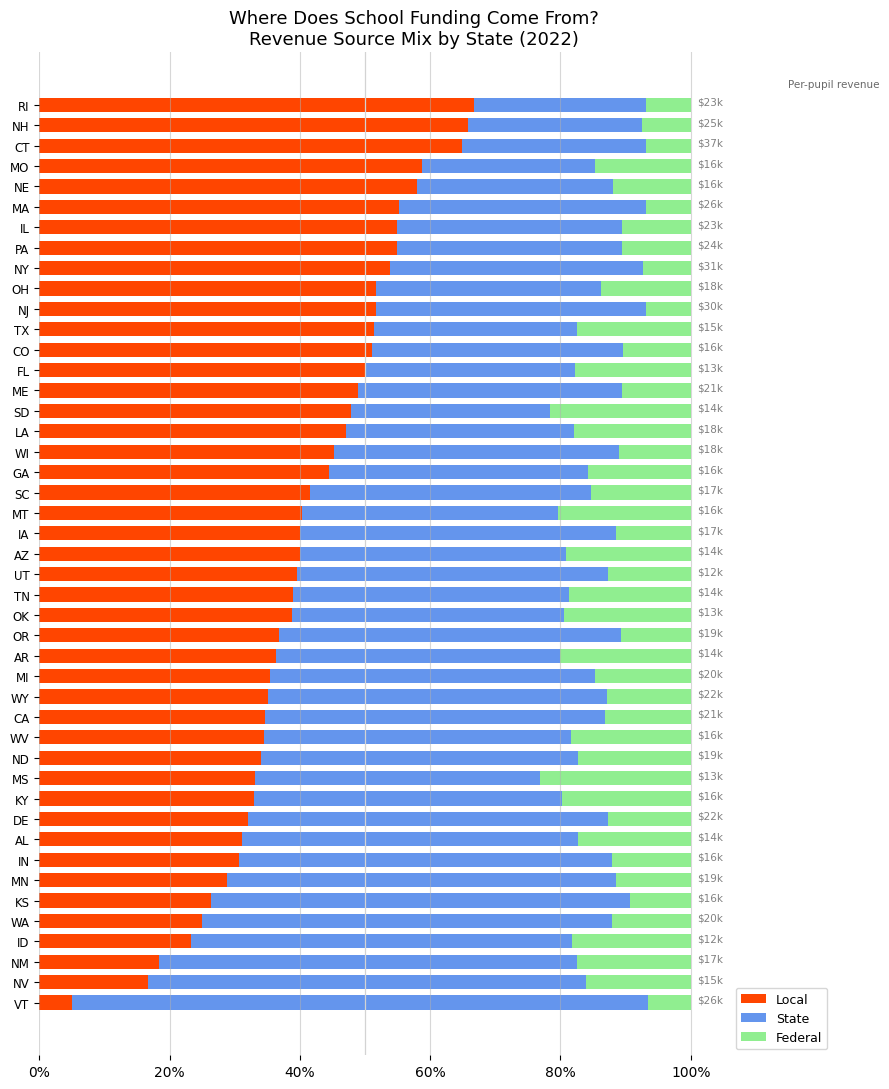

In [16]:
state_sorted = state.sort_values('pct_local').reset_index(drop=True)

y = np.arange(len(state_sorted))

fig, ax = plt.subplots(figsize=(9, 11))

local = state_sorted['pct_local']
state_amt = state_sorted['pct_state']
federal = state_sorted['pct_federal']

ax.barh(y, local, color='orangered', height=0.7, label='Local')
ax.barh(y, state_amt, left=local, color='cornflowerblue', height=0.7, label='State')
ax.barh(y, federal, left=local + state_amt, color='lightgreen', height=0.7, label='Federal')

# adds per-pupil revenue labels to the right of each bar!
for i, value in enumerate(state_sorted['pp_total']):
    ax.text(101, i, '$' + str(round(value / 1000)) + 'k', fontsize=7.5, color='gray')

ax.set_yticks(y)
# state abbreviations on y-axis
ax.set_yticklabels(state_sorted['STABBR'], fontsize=8.5)

ax.set_xlim(0, 115)
ax.axvline(50, color='lightgray', linewidth=0.9)

ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

ax.grid(axis='x', alpha=0.5)

ax.legend(loc='lower right', bbox_to_anchor=(1.06, 0), fontsize=9)

ax.text(115, len(state_sorted) - 0.10, 'Per-pupil revenue',
        fontsize=7.5, color='dimgray', ha='left')

#removes box around plot
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    'Where Does School Funding Come From?\nRevenue Source Mix by State (2022)',
    fontsize=13)

plt.tight_layout()
plt.savefig('viz1_revenue_sources.png', dpi=150, bbox_inches='tight')
plt.show()

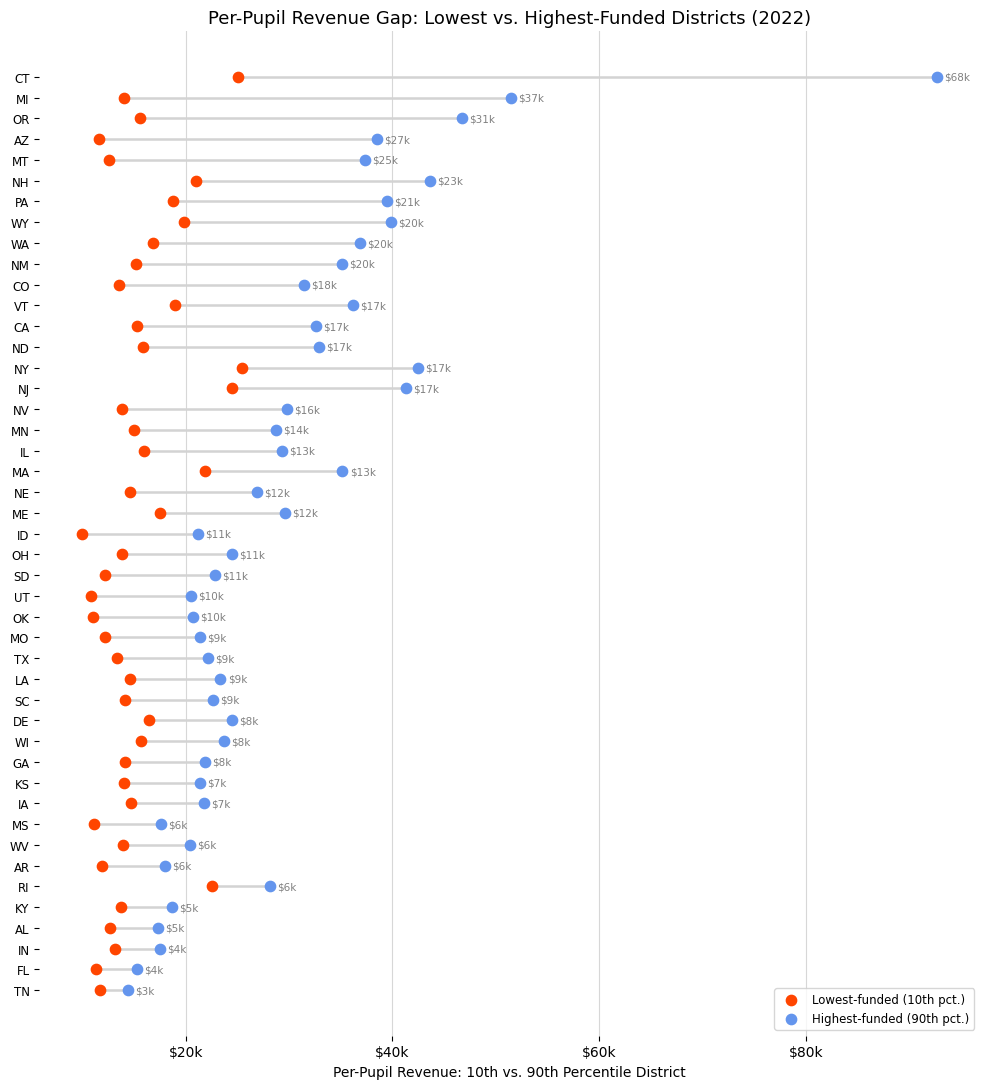

In [26]:
s = stats.sort_values('dollar_gap').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 11))

for i in range(len(s)):
    row = s.iloc[i]
    y = i

    # convert p10 and p90 to thousands of dollars
    p10 = row['p10'] / 1000
    p90 = row['p90'] / 1000

    # draw the horizontal line between the two values
    ax.hlines(y, p10, p90, color='lightgray', linewidth=1.8)

    # draw the two endpoint dots
    if i == 0:
        ax.scatter(p10, y, color='orangered', s=55, zorder=3,
                   label='Lowest-funded (10th pct.)')
        ax.scatter(p90, y, color='cornflowerblue', s=55, zorder=3,
                   label='Highest-funded (90th pct.)')
    else:
        ax.scatter(p10, y, color='orangered', s=55, zorder=3)
        ax.scatter(p90, y, color='cornflowerblue', s=55, zorder=3)

    # make the gap label
    gap_k = row['dollar_gap'] / 1000
    gap_label = '$' + str(round(gap_k)) + 'k'

    ax.text(
        p90 + 0.7,
        y,
        gap_label,
        va='center',
        fontsize=7.5,
        color='gray'
    )

ax.set_yticks(np.arange(len(s)))
ax.set_yticklabels(s['STABBR'], fontsize=8.5)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x:.0f}k'))
ax.grid(axis='x', alpha=0.5)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel('Per-Pupil Revenue: 10th vs. 90th Percentile District', fontsize=10)
ax.legend(fontsize=8.5, loc='lower right')

ax.set_title(
    'Per-Pupil Revenue Gap: Lowest vs. Highest-Funded Districts (2022)',
    fontsize=13
)

plt.tight_layout()
plt.savefig('vizA_dumbbell.png', dpi=150, bbox_inches='tight')
plt.show()

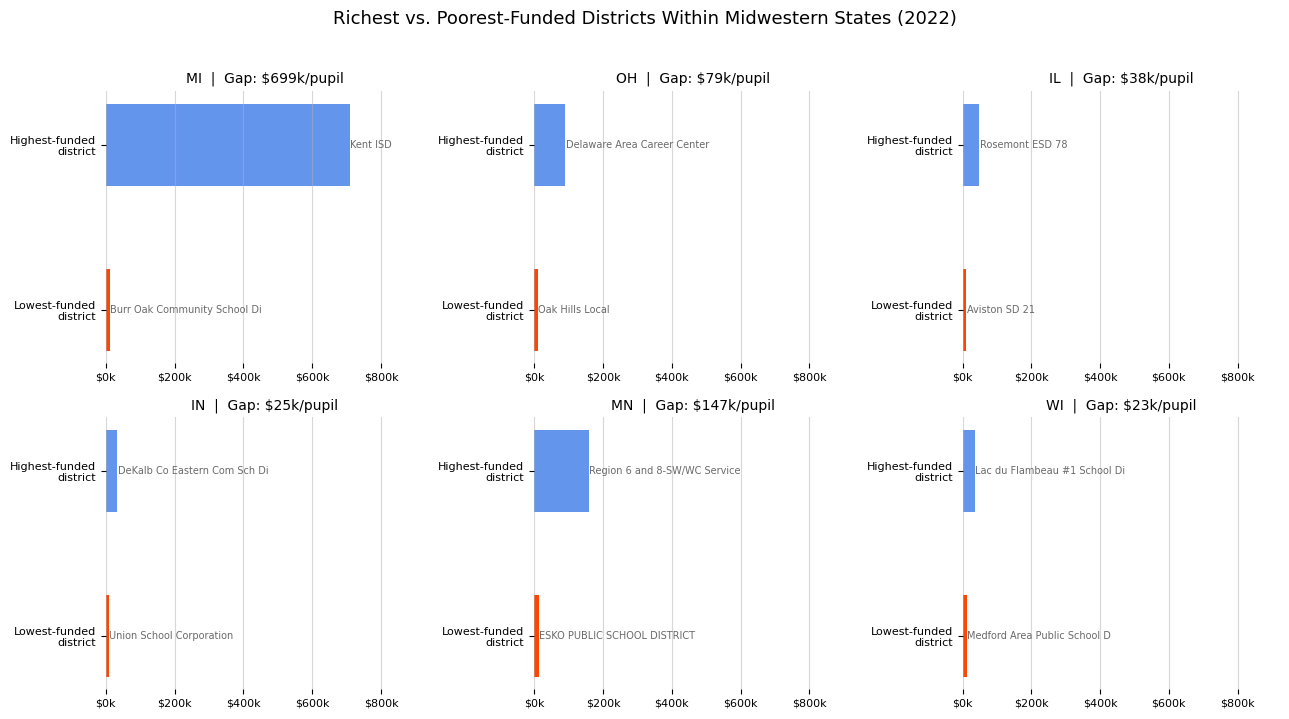

In [29]:
focus_states = ['MI', 'OH', 'IL', 'IN', 'MN', 'WI']

# find the largest per-pupil revenue value across these states
max_values = []

for state_name in focus_states:
    state_data = clean[(clean['STABBR'] == state_name) &(clean['MEMBERSCH'] >= 200)]
    max_value = state_data['pp_total'].max()
    max_values.append(max_value)

# convert to thousands 
shared_xmax = (max(max_values) / 1000) * 1.30

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

fig.suptitle(
    'Richest vs. Poorest-Funded Districts Within Midwestern States (2022)',
    fontsize=13,
    y=1.02)


axes_list = axes.flatten()

# one chart per state
for i in range(len(focus_states)):
    state_name = focus_states[i]
    ax = axes_list[i]

    # keep only info for this state
    state_data = clean[clean['STABBR'] == state_name]
    # keep only districts with at least 200 students
    state_data = state_data[state_data['MEMBERSCH'] >= 200]
    # sort districts from min per-pupil revenue to max
    state_data = state_data.sort_values('pp_total')

    low = state_data.iloc[0]
    high = state_data.iloc[-1]
    low_val = low['pp_total'] / 1000
    high_val = high['pp_total'] / 1000
    gap = high_val - low_val

    # shorten district names so they fit better on the chart
    low_name = low['NAME'][:28]
    high_name = high['NAME'][:28]

    bar_labels = ['Lowest-funded\ndistrict', 'Highest-funded\ndistrict']
    bar_values = [low_val, high_val]
    bar_colors = ['orangered', 'cornflowerblue']

    # draw the bars
    ax.barh(bar_labels, bar_values, color=bar_colors, height=0.5)

    # add the district names at the end of each bar
    ax.text(low_val + 0.4, 0, low_name, fontsize=7, color='dimgray', va='center')

    ax.text(high_val + 0.4, 1, high_name, fontsize=7, color='dimgray', va='center' )

    # make the title for this subplot
    title_text = state_name + '  |  Gap: $' + str(round(gap)) + 'k/pupil'

    ax.set_title(
        title_text,
        fontsize=10)


    ax.set_xlim(0, shared_xmax)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: '$' + str(round(x)) + 'k'))

    ax.grid(axis='x', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('vizC_zip_code_lottery.png', dpi=150, bbox_inches='tight')
plt.show()

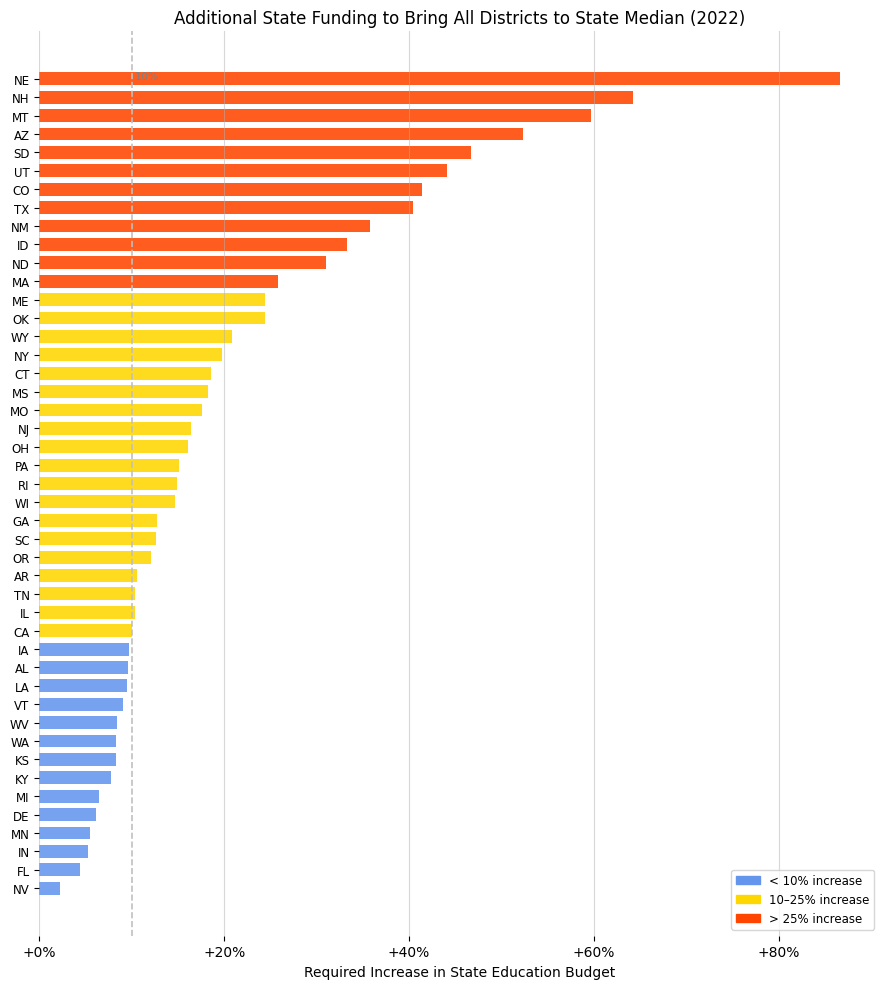

In [30]:
def equalization_cost(group):
    per_pupil = group['pp_total'].dropna()
    # find the state median per-pupil revenue
    median_per_pupil = per_pupil.median()
    deficit = median_per_pupil - per_pupil
    deficit = deficit.clip(lower=0)
    students = group.loc[per_pupil.index, 'MEMBERSCH']

    # total extra money needed = deficit per student × number of students
    extra_needed = (deficit * students).sum()
    total_state_revenue = group['TSTREV'].sum()

    # percent increase needed in the state budget
    pct_increase_needed = (extra_needed / total_state_revenue) * 100

    return pd.Series({'extra_needed': extra_needed,
        'pct_increase_needed': pct_increase_needed})

eq = clean.groupby('STABBR').apply(equalization_cost, include_groups=False).reset_index()
# only states needing extra funding!
eq = eq[eq['extra_needed'] > 0]
eq = eq.sort_values('pct_increase_needed')


# choose bar colors based on the size of the increase needed
bar_colors = []

for value in eq['pct_increase_needed']:
    if value <= 10:
        color = 'cornflowerblue'
    elif value <= 25:
        color = 'gold'
    else:
        color = 'orangered'

    bar_colors.append(color)


fig, ax = plt.subplots(figsize=(9, 10))

# draw the bars
ax.barh(range(len(eq)),
    eq['pct_increase_needed'],
    color=bar_colors,
    alpha=0.88,
    height=0.7)

# label each bar with the state abbreviation
ax.set_yticks(range(len(eq)))
ax.set_yticklabels(eq['STABBR'], fontsize=8.5)


# format x-axis labels like +5%, +10%, etc.
def percent_label(x, pos):
    return '+' + str(round(x)) + '%'

ax.xaxis.set_major_formatter(mticker.FuncFormatter(percent_label))

ax.axvline(10, color='silver', linewidth=1.2, linestyle='--')
ax.text(10.3, len(eq) - 1, '10%', color='gray', fontsize=8)


ax.grid(axis='x', alpha=0.5)


for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel('Required Increase in State Education Budget', fontsize=10)

legend_elements = [
    mpatches.Patch(color='cornflowerblue', label='< 10% increase'),
    mpatches.Patch(color='gold', label='10–25% increase'),
    mpatches.Patch(color='orangered', label='> 25% increase')]

ax.legend(handles=legend_elements, fontsize=8.5, loc='lower right')

ax.set_title(
    'Additional State Funding to Bring All Districts to State Median (2022)',
    fontsize=12)

plt.tight_layout()
plt.savefig('vizD_equalization_cost.png', dpi=150, bbox_inches='tight')
plt.show()